# Experiment 3: Fine-Tuning with QLoRA

Fine-tuning LLaMA-3.1-8B-Instruct on Solana vulnerability detection using QLoRA.


## Step 1: Check GPU

In [1]:
import torch

if not torch.cuda.is_available():
    raise RuntimeError("GPU required!")

print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

GPU: Tesla T4
Memory: 15.8 GB


## Step 2: Install Packages

In [2]:
!pip install -q bitsandbytes accelerate peft trl

print("Installation complete!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 32.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 517.4/517.4 kB 29.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 103.7 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 61.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 35.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00:00:0100:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 8.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 31.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## Step 3: Imports

In [3]:
import json
import glob
import warnings
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict, Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from tqdm import tqdm

from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    TrainingArguments
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from trl import SFTTrainer
from datasets import Dataset
from huggingface_hub import login

os.environ["WANDB_DISABLED"] = "true"
warnings.filterwarnings('ignore')
print("Imports done!")

2025-12-15 14:53:50.322748: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765810430.520974      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765810430.584116      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

Imports done!


## Step 4: HuggingFace Login

In [4]:
from kaggle_secrets import UserSecretsClient
HF_TOKEN = UserSecretsClient().get_secret("HF_TOKEN")
login(token=HF_TOKEN)
print("Logged in!")

Logged in!


## Step 5: Load Dataset

In [5]:
json_files = glob.glob('/kaggle/input/**/*.json', recursive=True)
print(f"Found: {json_files}")

dataset_raw = None
for f in json_files:
    with open(f, 'r') as file:
        data = json.load(file)
    if isinstance(data, list) and len(data) > 100:
        dataset_raw = data
        print(f"Loaded: {len(dataset_raw)} samples")
        break

if dataset_raw is None:
    raise FileNotFoundError("Dataset not found!")

Found: ['/kaggle/input/solana-dataset/solana_182_final.json']
Loaded: 182 samples


## Step 6: Split Dataset (80/10/10)

In [6]:
by_type = defaultdict(list)
for sample in dataset_raw:
    by_type[sample['vulnerability_type']].append(sample)

train_data, val_data, test_data = [], [], []

for vtype, samples in by_type.items():
    labels = [s['label'] for s in samples]
    train_s, temp_s = train_test_split(samples, test_size=0.2, stratify=labels, random_state=42)
    temp_labels = [s['label'] for s in temp_s]
    val_s, test_s = train_test_split(temp_s, test_size=0.5, stratify=temp_labels, random_state=42)
    
    train_data.extend(train_s)
    val_data.extend(val_s)
    test_data.extend(test_s)

print(f"Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}")
print(f"Train labels: {Counter(s['label'] for s in train_data)}")

Train: 140 | Val: 21 | Test: 21
Train labels: Counter({'VULNERABLE': 70, 'SAFE': 70})


## Step 7: Load Model with 4-bit Quantization

In [7]:
MODEL_ID = "meta-llama/Llama-3.1-8B-Instruct"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)

print("Loading model... (2-3 minutes)")

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, token=HF_TOKEN)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    token=HF_TOKEN,
    torch_dtype=torch.float16
)

print(f"Model loaded: {MODEL_ID}")

Loading model... (2-3 minutes)


tokenizer_config.json:   0%|          | 0.00/55.4k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

...

model-00004-of-00004.safetensors:   0%|          | 0.00/1.17G [00:00<?, ?B/s]

model-00003-of-00004.safetensors:   0%|          | 0.00/4.92G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/184 [00:00<?, ?B/s]

Model loaded: meta-llama/Llama-3.1-8B-Instruct


## Step 8: Configure LoRA

In [8]:
model = prepare_model_for_kbit_training(model)

lora_config = LoraConfig(
    r=64,
    lora_alpha=16,
    lora_dropout=0.1,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"]
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

trainable params: 54,525,952 || all params: 8,084,787,200 || trainable%: 0.6744


## Step 9: Prepare Datasets

In [9]:
train_dataset = Dataset.from_list([{"text": s["text"]} for s in train_data])
val_dataset = Dataset.from_list([{"text": s["text"]} for s in val_data])

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)}")

Train: 140 | Val: 21


## Step 10: Training

This will take approximately 15-25 minutes.

In [10]:
training_args = TrainingArguments(
    output_dir="/kaggle/working/checkpoints",
    num_train_epochs=3,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=4,
    optim="adamw_torch",
    learning_rate=2e-4,
    weight_decay=0.01,
    warmup_ratio=0.03,
    lr_scheduler_type="cosine",
    logging_steps=10,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    load_best_model_at_end=True,
    report_to="none",
    fp16=False,
    bf16=False,
    max_grad_norm=0.3,
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant": False}
)

trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer
)

print("Starting training...")
trainer.train()
print("Training complete!")

Adding EOS to train dataset:   0%|          | 0/140 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/140 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/140 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/21 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/21 [00:00<?, ? examples/s]

...

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 128009, 'pad_token_id': 128009}.


Starting training...


Epoch,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
1,1.625200,0.869637,0.909259,52161.000000,0.805761
2,0.745000,0.707865,0.713741,104322.000000,0.836360
3,0.638200,0.692314,0.694862,156483.000000,0.839578


Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


Training complete!


## Step 11: Save Model

In [11]:
model.save_pretrained("/kaggle/working/fine_tuned_model")
tokenizer.save_pretrained("/kaggle/working/fine_tuned_model")
print("Model saved!")

Model saved!


## Step 12: Prediction Function

In [12]:
model.eval()

def extract_code(sample):
    text = sample.get('text', '')
    if '<|start_header_id|>user<|end_header_id|>' in text:
        start = text.find('<|start_header_id|>user<|end_header_id|>') + len('<|start_header_id|>user<|end_header_id|>')
        end = text.find('<|eot_id|><|start_header_id|>assistant')
        if end > start:
            code = text[start:end].strip()
            return code.replace('```rust', '').replace('```', '').strip()
    return text[:1500]

def predict(sample):
    code = extract_code(sample)
    
    prompt = f"""<|begin_of_text|><|start_header_id|>system<|end_header_id|>

You are a Solana smart contract security auditor. Analyze the provided Rust code for vulnerabilities.
Classify the code as either VULNERABLE or SAFE.<|eot_id|><|start_header_id|>user<|end_header_id|>

```rust
{code[:1000]}
```<|eot_id|><|start_header_id|>assistant<|end_header_id|>

"""
    
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=1500)
    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=10,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )
    
    response = tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
    response = response.strip().upper()
    
    if 'VULNERABLE' in response:
        return 'VULNERABLE'
    elif 'SAFE' in response:
        return 'SAFE'
    return 'VULNERABLE'

print("Prediction function ready!")

Prediction function ready!


## Step 13: Evaluation

In [13]:
print(f"Evaluating on {len(test_data)} test samples...")

results = []
for sample in tqdm(test_data, desc="Testing"):
    pred = predict(sample)
    results.append({
        'vulnerability_type': sample['vulnerability_type'],
        'ground_truth': sample['label'],
        'prediction': pred,
        'correct': sample['label'] == pred
    })

print(f"Done! Correct: {sum(r['correct'] for r in results)}/{len(results)}")

Evaluating on 21 test samples...


Testing: 100%|██████████| 21/21 [00:14<00:00,  1.43it/s]

Done! Correct: 14/21


## Step 14: Detailed Results

In [14]:
print("\nDetailed Results:")
print("-" * 70)
for i, r in enumerate(results, 1):
    status = "✓" if r['correct'] else "✗"
    print(f"{i:2}. {r['vulnerability_type']:<20} True: {r['ground_truth']:<12} Pred: {r['prediction']:<12} {status}")
print("-" * 70)


Detailed Results:
----------------------------------------------------------------------
 1. Integer Flow         True: SAFE         Pred: VULNERABLE   ✗
 2. Integer Flow         True: SAFE         Pred: SAFE         ✓
 3. Integer Flow         True: VULNERABLE   Pred: SAFE         ✗
 4. Type Confusion       True: SAFE         Pred: SAFE         ✓
 5. Type Confusion       True: SAFE         Pred: SAFE         ✓
 6. Type Confusion       True: VULNERABLE   Pred: VULNERABLE   ✓
 7. DoS                  True: SAFE         Pred: SAFE         ✓
 8. DoS                  True: SAFE         Pred: SAFE         ✓
 9. DoS                  True: VULNERABLE   Pred: SAFE         ✗
10. Bump Seed            True: SAFE         Pred: SAFE         ✓
11. Bump Seed            True: SAFE         Pred: SAFE         ✓
12. Bump Seed            True: VULNERABLE   Pred: SAFE         ✗
13. Unchecked Calls      True: SAFE         Pred: SAFE         ✓
14. Unchecked Calls      True: SAFE         Pred: SAFE         ✓


## Step 15: Calculate Metrics

In [15]:
all_gt = [r['ground_truth'] for r in results]
all_pred = [r['prediction'] for r in results]

accuracy = accuracy_score(all_gt, all_pred)
precision = precision_score(all_gt, all_pred, pos_label='VULNERABLE', zero_division=0)
recall = recall_score(all_gt, all_pred, pos_label='VULNERABLE', zero_division=0)
f1 = f1_score(all_gt, all_pred, pos_label='VULNERABLE', zero_division=0)

print("=" * 50)
print("EXPERIMENT 3: FINE-TUNING RESULTS")
print("=" * 50)
print(f"Accuracy:  {accuracy:.2%}")
print(f"Precision: {precision:.2%}")
print(f"Recall:    {recall:.2%}")
print(f"F1-Score:  {f1:.2%}")
print("=" * 50)

EXPERIMENT 3: FINE-TUNING RESULTS
Accuracy:  66.67%
Precision: 50.00%
Recall:    28.57%
F1-Score:  36.36%


## Step 16: Per-Vulnerability Performance

In [16]:
print("\nPer-Vulnerability Type:")
print("-" * 50)

metrics_by_type = {}
for vtype in sorted(set(r['vulnerability_type'] for r in results)):
    type_results = [r for r in results if r['vulnerability_type'] == vtype]
    gt = [r['ground_truth'] for r in type_results]
    pred = [r['prediction'] for r in type_results]
    acc = accuracy_score(gt, pred)
    metrics_by_type[vtype] = {'accuracy': acc, 'count': len(type_results)}
    print(f"{vtype:<20}: {acc:.2%} ({len(type_results)} samples)")

print("-" * 50)
print(f"{'AVERAGE':<20}: {np.mean([m['accuracy'] for m in metrics_by_type.values()]):.2%}")


Per-Vulnerability Type:
--------------------------------------------------
Bump Seed           : 66.67% (3 samples)
CPI                 : 33.33% (3 samples)
DoS                 : 66.67% (3 samples)
Integer Flow        : 33.33% (3 samples)
Missing Key Check   : 100.00% (3 samples)
Type Confusion      : 100.00% (3 samples)
Unchecked Calls     : 66.67% (3 samples)
--------------------------------------------------
AVERAGE             : 66.67%


## Step 17: Confusion Matrix

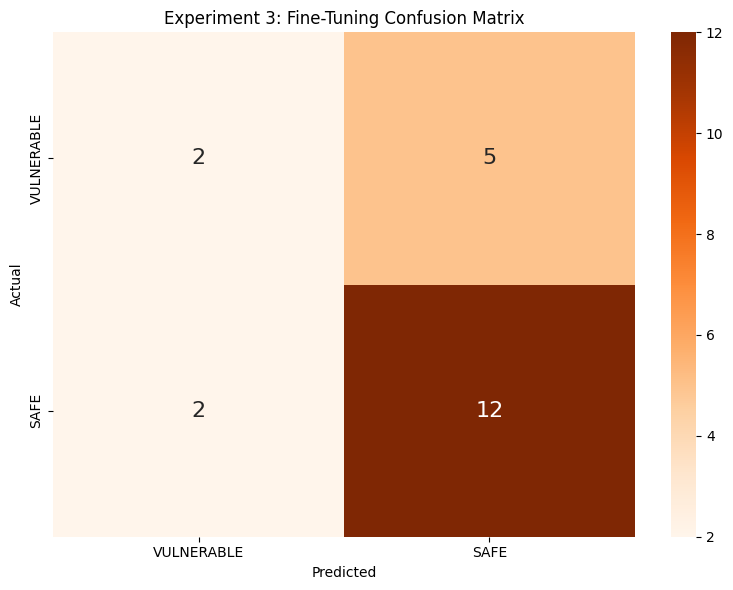


TP: 2 | FN: 5
FP: 2 | TN: 12


In [17]:
cm = confusion_matrix(all_gt, all_pred, labels=['VULNERABLE', 'SAFE'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['VULNERABLE', 'SAFE'],
            yticklabels=['VULNERABLE', 'SAFE'],
            annot_kws={'size': 16})
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Experiment 3: Fine-Tuning Confusion Matrix')
plt.tight_layout()
plt.savefig('/kaggle/working/cm_fine_tuning.png', dpi=150)
plt.show()

print(f"\nTP: {cm[0,0]} | FN: {cm[0,1]}")
print(f"FP: {cm[1,0]} | TN: {cm[1,1]}")

## Step 18: Save Results

In [18]:
pd.DataFrame(results).to_csv('/kaggle/working/results_fine_tuning.csv', index=False)

summary = {
    'experiment': 'Fine-Tuning with QLoRA',
    'model': MODEL_ID,
    'training': {'epochs': 3, 'learning_rate': 2e-4, 'lora_r': 64, 'lora_alpha': 16},
    'dataset_size': len(dataset_raw),
    'train_size': len(train_data),
    'test_size': len(test_data),
    'results': {
        'accuracy': round(accuracy, 4),
        'precision': round(precision, 4),
        'recall': round(recall, 4),
        'f1_score': round(f1, 4)
    },
    'confusion_matrix': {'TP': int(cm[0,0]), 'FN': int(cm[0,1]), 'FP': int(cm[1,0]), 'TN': int(cm[1,1])},
    'per_vulnerability': metrics_by_type
}

with open('/kaggle/working/summary_fine_tuning.json', 'w') as f:
    json.dump(summary, f, indent=2)

print("Saved: results_fine_tuning.csv, summary_fine_tuning.json, cm_fine_tuning.png")

Saved: results_fine_tuning.csv, summary_fine_tuning.json, cm_fine_tuning.png


## Final Summary

In [19]:
print("\n" + "=" * 50)
print("EXPERIMENT 3 COMPLETE")
print("=" * 50)
print(f"Method: Fine-Tuning with QLoRA")
print(f"Model: {MODEL_ID}")
print(f"Training: {len(train_data)} samples, 3 epochs")
print(f"\nResults:")
print(f"  Accuracy:  {accuracy:.2%}")
print(f"  Precision: {precision:.2%}")
print(f"  Recall:    {recall:.2%}")
print(f"  F1-Score:  {f1:.2%}")
print("=" * 50)


EXPERIMENT 3 COMPLETE
Method: Fine-Tuning with QLoRA
Model: meta-llama/Llama-3.1-8B-Instruct
Training: 140 samples, 3 epochs

Results:
  Accuracy:  66.67%
  Precision: 50.00%
  Recall:    28.57%
  F1-Score:  36.36%
